<a href="https://colab.research.google.com/github/himanshu561hi/CBSOT/blob/main/heartdisease_enhanced_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Heart Disease Prediction
### Cleveland Heart Disease Dataset — End-to-End ML Pipeline
> **Google Colab Compatible** | Logistic Regression · Random Forest · XGBoost · Feature Importance · ROC Curve · SHAP Explainability


## 1. Install Dependencies & Import Libraries

In [ ]:
# Install any missing packages (safe to run in Colab)
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import xgboost
except ImportError:
    install("xgboost")

try:
    import shap
except ImportError:
    install("shap")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve,
    classification_report, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import shap

sns.set_theme(style="whitegrid", palette="Set2")
print("All libraries imported successfully!")


All libraries imported successfully!


## 2. Load Dataset
The **Cleveland Heart Disease** dataset from the UCI ML Repository is loaded directly — no manual upload needed in Colab.

In [ ]:
import urllib.request, os

URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
LOCAL = "processed.cleveland.data"

if not os.path.exists(LOCAL):
    print("⬇️  Downloading dataset from UCI repository...")
    urllib.request.urlretrieve(URL, LOCAL)
    print("Downloaded successfully!")
else:
    print("Dataset already exists locally.")

columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol',
    'fbs', 'restecg', 'thalach', 'exang',
    'oldpeak', 'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv(LOCAL, names=columns)
print(f"\nDataset shape: {df.shape}")
df.head()


Dataset already exists locally.

Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 3. Exploratory Data Analysis (EDA)

In [ ]:
print("=== Dataset Info ===")
df.info()
print("\n=== Basic Statistics ===")
df.describe()


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB

=== Basic Statistics ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


In [ ]:
# Check for missing values (encoded as '?')
print("Missing values (before cleaning):")
df_temp = df.replace('?', np.nan)
print(df_temp.isnull().sum())
print(f"\nTarget distribution:\n{df['target'].value_counts()}")


Missing values (before cleaning):
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Target distribution:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


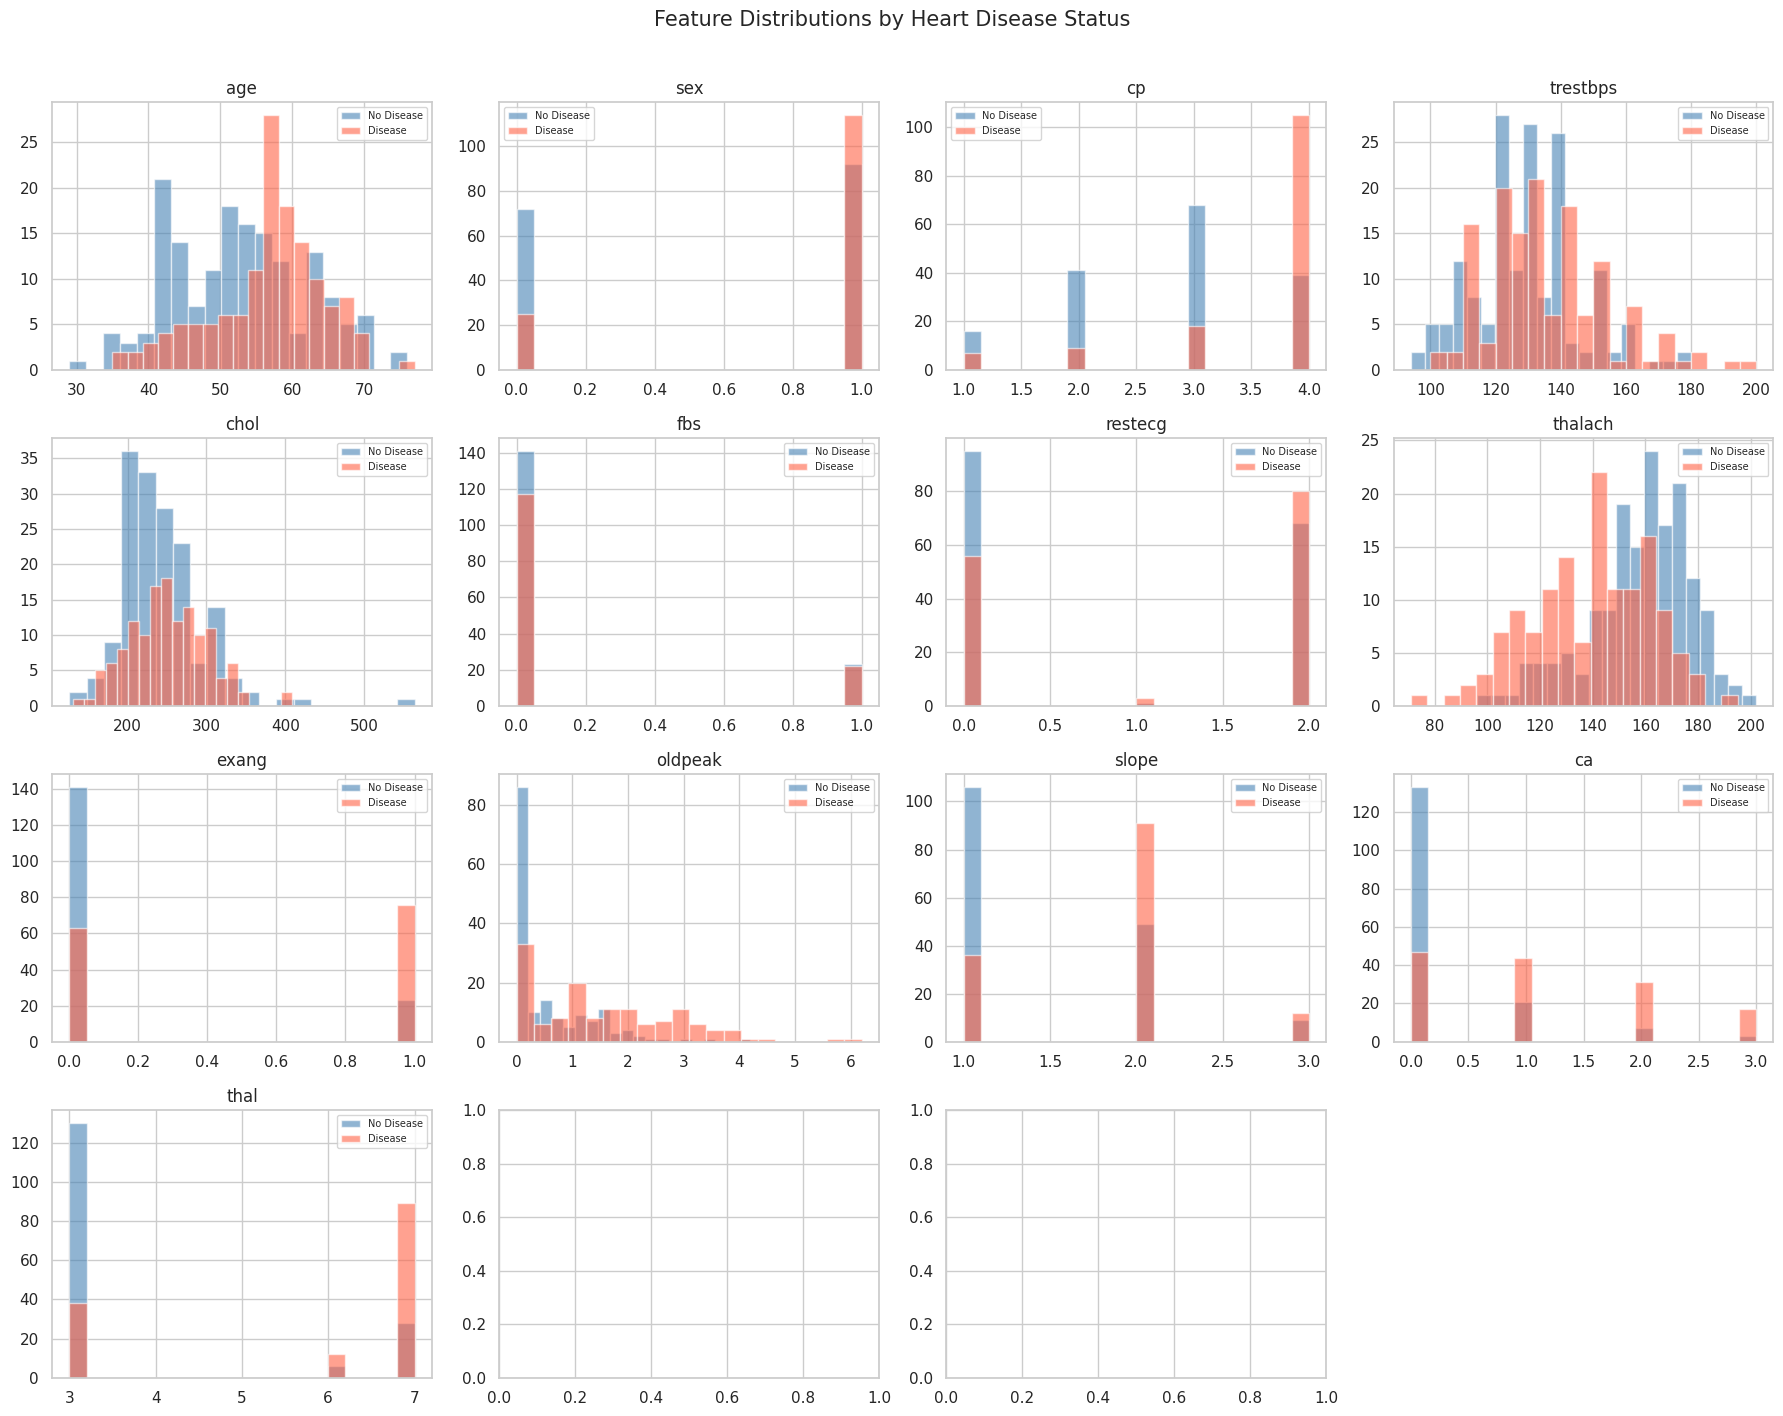

Feature distribution plots saved.


In [ ]:
# ── Distribution plots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

df_temp = df.replace('?', np.nan)
df_temp['ca'] = pd.to_numeric(df_temp['ca'], errors='coerce')
df_temp['thal'] = pd.to_numeric(df_temp['thal'], errors='coerce')
df_temp.fillna(df_temp.median(numeric_only=True), inplace=True)
df_temp['target'] = df_temp['target'].apply(lambda x: 0 if x == 0 else 1)

for i, col in enumerate(columns[:-1]):
    axes[i].hist(df_temp[df_temp['target']==0][col], alpha=0.6, label='No Disease', color='steelblue', bins=20)
    axes[i].hist(df_temp[df_temp['target']==1][col], alpha=0.6, label='Disease', color='tomato', bins=20)
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

axes[-1].axis('off')  # hide last empty subplot
plt.suptitle("Feature Distributions by Heart Disease Status", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=120, bbox_inches='tight')
plt.show()
print("Feature distribution plots saved.")


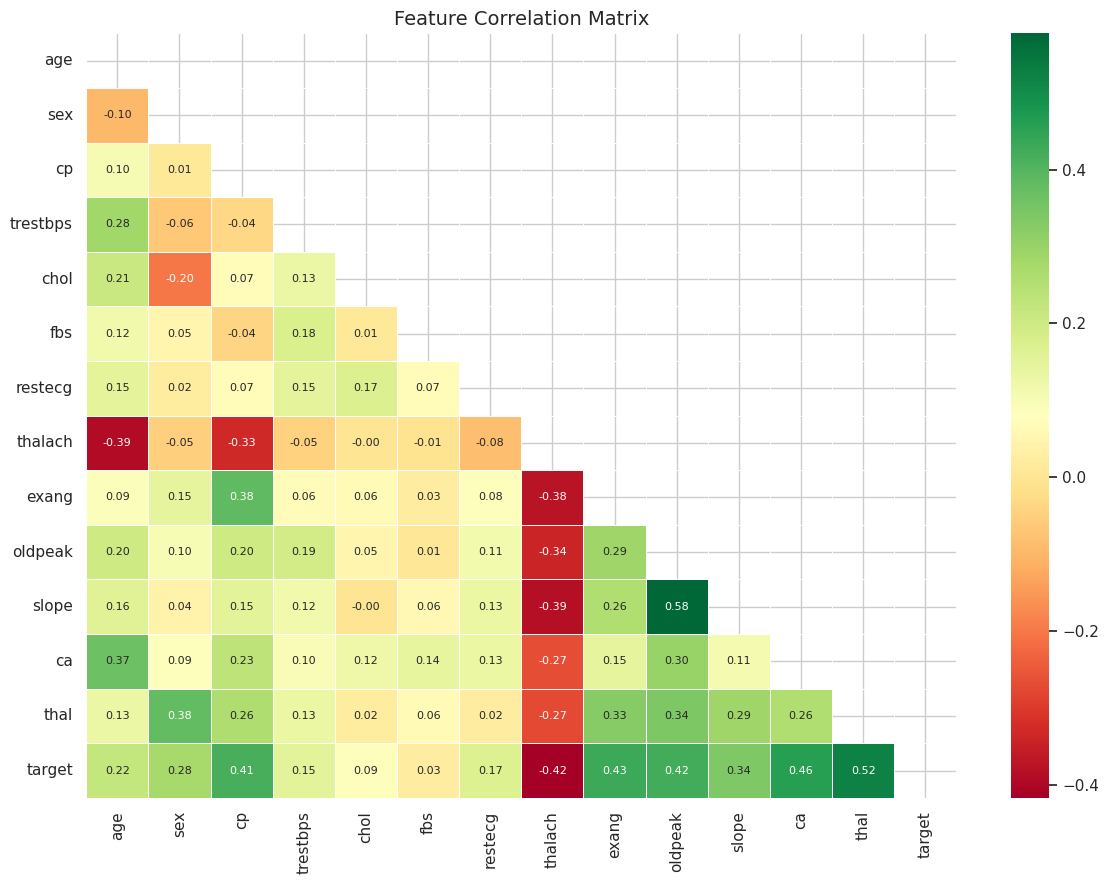

Correlation heatmap saved.


In [ ]:
# ── Correlation heatmap ──────────────────────────────────────────────────────
plt.figure(figsize=(12, 9))
corr = df_temp.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            linewidths=0.5, annot_kws={"size": 8})
plt.title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=120, bbox_inches='tight')
plt.show()
print("Correlation heatmap saved.")


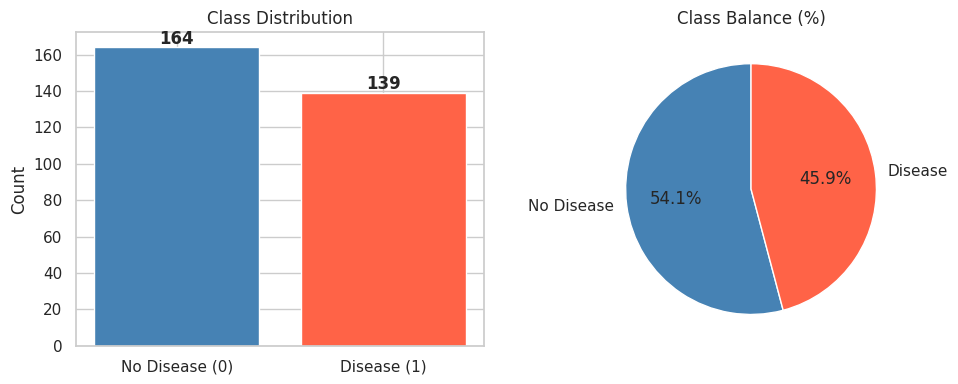

In [ ]:
# ── Target class balance ─────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

counts = df_temp['target'].value_counts()
ax1.bar(['No Disease (0)', 'Disease (1)'], counts.values, color=['steelblue', 'tomato'], edgecolor='white')
ax1.set_title("Class Distribution")
ax1.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax1.text(i, v + 2, str(v), ha='center', fontweight='bold')

ax2.pie(counts.values, labels=['No Disease', 'Disease'], autopct='%1.1f%%',
        colors=['steelblue', 'tomato'], startangle=90)
ax2.set_title("Class Balance (%)")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=120, bbox_inches='tight')
plt.show()


## 4. Data Preprocessing

In [ ]:
# Start fresh from raw df
df_clean = df.copy()

# Replace '?' with NaN
df_clean.replace('?', np.nan, inplace=True)

# Convert mixed-type columns to numeric
df_clean['ca'] = pd.to_numeric(df_clean['ca'], errors='coerce')
df_clean['thal'] = pd.to_numeric(df_clean['thal'], errors='coerce')

# Fill NaNs with column median
df_clean.fillna(df_clean.median(numeric_only=True), inplace=True)

# Binarize target (0 = no disease, 1 = disease)
df_clean['target'] = df_clean['target'].apply(lambda x: 0 if x == 0 else 1)

print(f"Shape after cleaning: {df_clean.shape}")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")
print(f"\nTarget distribution:\n{df_clean['target'].value_counts()}")


Shape after cleaning: (303, 14)
Missing values remaining: 0

Target distribution:
target
0    164
1    139
Name: count, dtype: int64


## 5. Feature Engineering (New Additions)

In [ ]:
# Age group binning
df_clean['age_group'] = pd.cut(df_clean['age'],
                                bins=[0, 40, 50, 60, 100],
                                labels=['<40', '40-50', '50-60', '60+'])
df_clean['age_group'] = LabelEncoder().fit_transform(df_clean['age_group'])

# Cholesterol risk flag
df_clean['high_chol'] = (df_clean['chol'] > 240).astype(int)

# Hypertension flag (resting BP > 140 mmHg)
df_clean['hypertension'] = (df_clean['trestbps'] > 140).astype(int)

# Max heart rate achieved relative to predicted max (220 - age)
df_clean['hr_ratio'] = df_clean['thalach'] / (220 - df_clean['age'])

print("New features added: age_group, high_chol, hypertension, hr_ratio")
df_clean[['age', 'age_group', 'chol', 'high_chol', 'trestbps', 'hypertension', 'thalach', 'hr_ratio']].head()


New features added: age_group, high_chol, hypertension, hr_ratio


,age,age_group,chol,high_chol,trestbps,hypertension,thalach,hr_ratio
0,63.0,2,233.0,0,145.0,1,150.0,0.955414
1,67.0,2,286.0,1,160.0,1,108.0,0.705882
2,67.0,2,229.0,0,120.0,0,129.0,0.843137
3,37.0,3,250.0,1,130.0,0,187.0,1.021858
4,41.0,0,204.0,0,130.0,0,172.0,0.960894


## 6. Train/Test Split & Feature Scaling

In [ ]:
X = df_clean.drop('target', axis=1)
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Training samples : {X_train_s.shape[0]}")
print(f"Testing  samples : {X_test_s.shape[0]}")
print(f"Features         : {X_train_s.shape[1]}")


Training samples : 242
Testing  samples : 61
Features         : 17


## 7. Train Multiple Models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost"            : XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0)
}

# Cross-validation (5-fold stratified)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_s, y_train, cv=cv, scoring='accuracy')
    model.fit(X_train_s, y_train)
    y_pred  = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1]
    results[name] = {
        "model"   : model,
        "y_pred"  : y_pred,
        "y_proba" : y_proba,
        "cv_mean" : cv_scores.mean(),
        "cv_std"  : cv_scores.std(),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall"  : recall_score(y_test, y_pred),
        "f1"      : f1_score(y_test, y_pred),
        "roc_auc" : roc_auc_score(y_test, y_proba),
    }
    print(f"{name} trained.")

print("\nAll models trained successfully!")


✅ Logistic Regression trained.
✅ Random Forest trained.
✅ XGBoost trained.

All models trained successfully!


## 8. Model Evaluation & Comparison

In [ ]:
summary = pd.DataFrame([
    {
        "Model"    : name,
        "CV Acc (mean)": f"{r['cv_mean']:.4f}",
        "CV Acc (±std)" : f"{r['cv_std']:.4f}",
        "Test Acc" : f"{r['accuracy']:.4f}",
        "Precision": f"{r['precision']:.4f}",
        "Recall"   : f"{r['recall']:.4f}",
        "F1 Score" : f"{r['f1']:.4f}",
        "ROC-AUC"  : f"{r['roc_auc']:.4f}",
    }
    for name, r in results.items()
])
summary


,Model,CV Acc (mean),CV Acc (±std),Test Acc,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8179,0.0411,0.8852,0.8387,0.9286,0.8814,0.9524
1,Random Forest,0.8138,0.0308,0.9180,0.8966,0.9286,0.9123,0.9589
2,XGBoost,0.7934,0.0294,0.8689,0.8125,0.9286,0.8667,0.9286


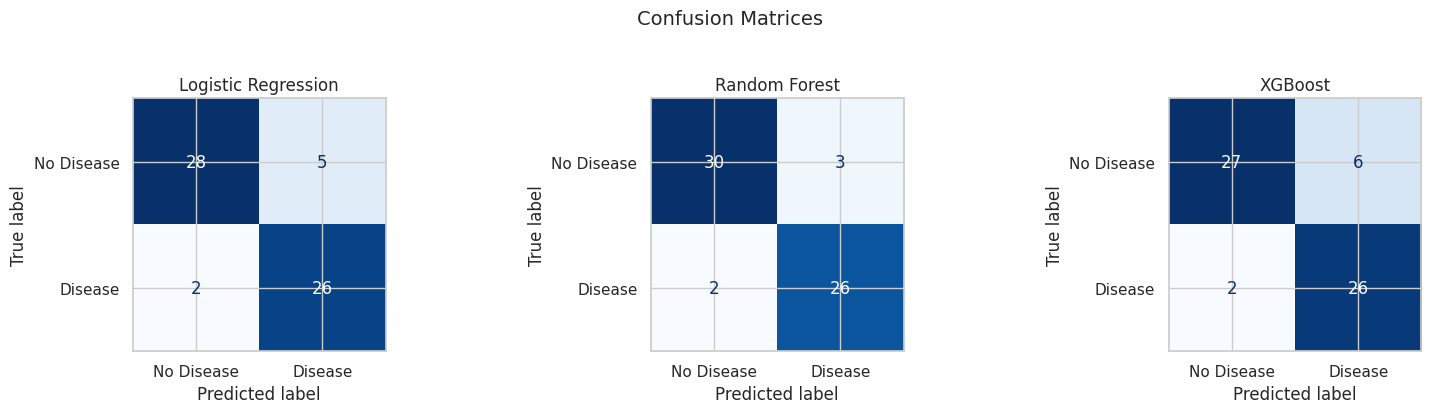

In [ ]:
# ── Confusion matrices side-by-side ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12)

plt.suptitle("Confusion Matrices", fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=120, bbox_inches='tight')
plt.show()


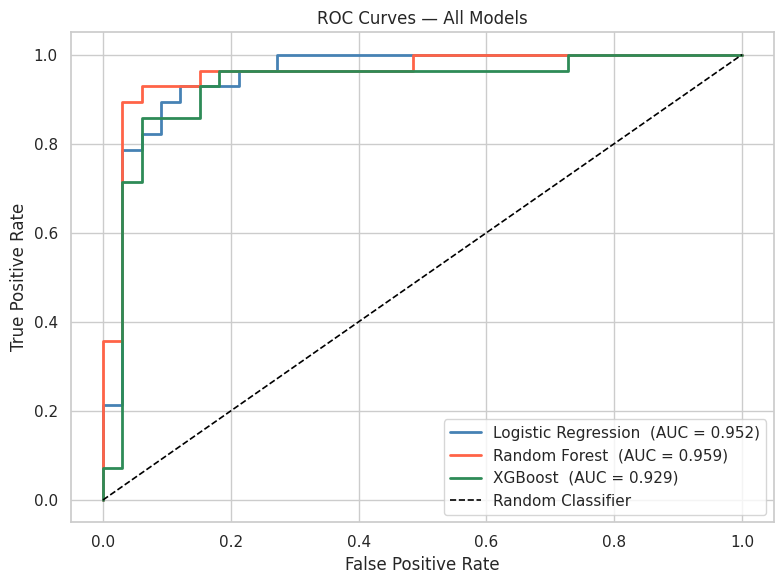

In [ ]:
# ── ROC curves ───────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
colors = ['steelblue', 'tomato', 'seagreen']

for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    plt.plot(fpr, tpr, label=f"{name}  (AUC = {r['roc_auc']:.3f})", color=color, lw=2)

plt.plot([0,1],[0,1], 'k--', lw=1.2, label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=120, bbox_inches='tight')
plt.show()


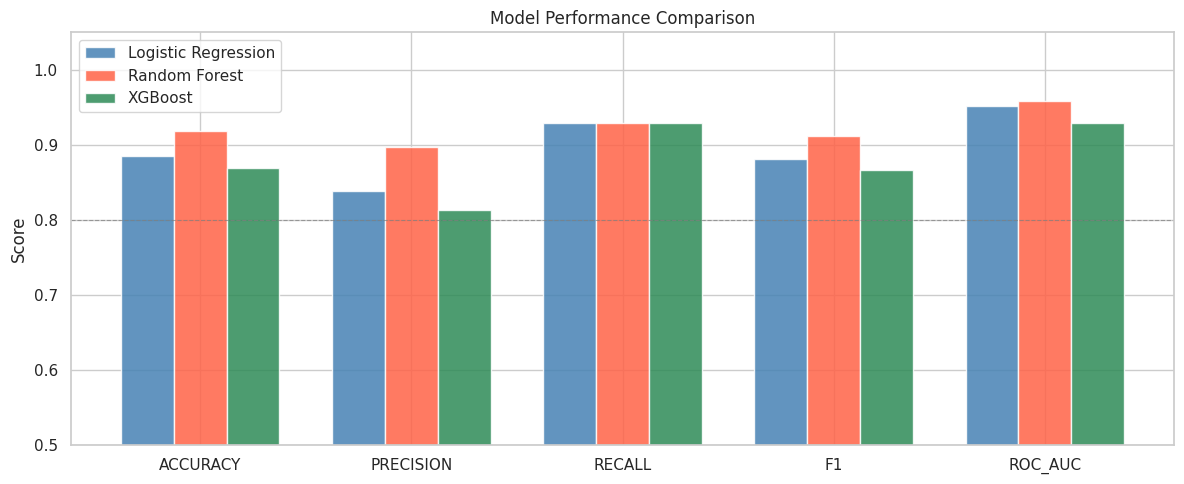

In [ ]:
# ── Metric bar chart ────────────────────────────────────────────────────────
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['steelblue', 'tomato', 'seagreen']

for i, (name, r) in enumerate(results.items()):
    vals = [r[m] for m in metrics]
    ax.bar(x + i*width, vals, width, label=name, color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels([m.upper() for m in metrics])
ax.set_ylim(0.5, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.legend()
ax.axhline(y=0.8, linestyle='--', color='gray', linewidth=0.8, alpha=0.7)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120, bbox_inches='tight')
plt.show()


## 9. Feature Importance (Random Forest + XGBoost)

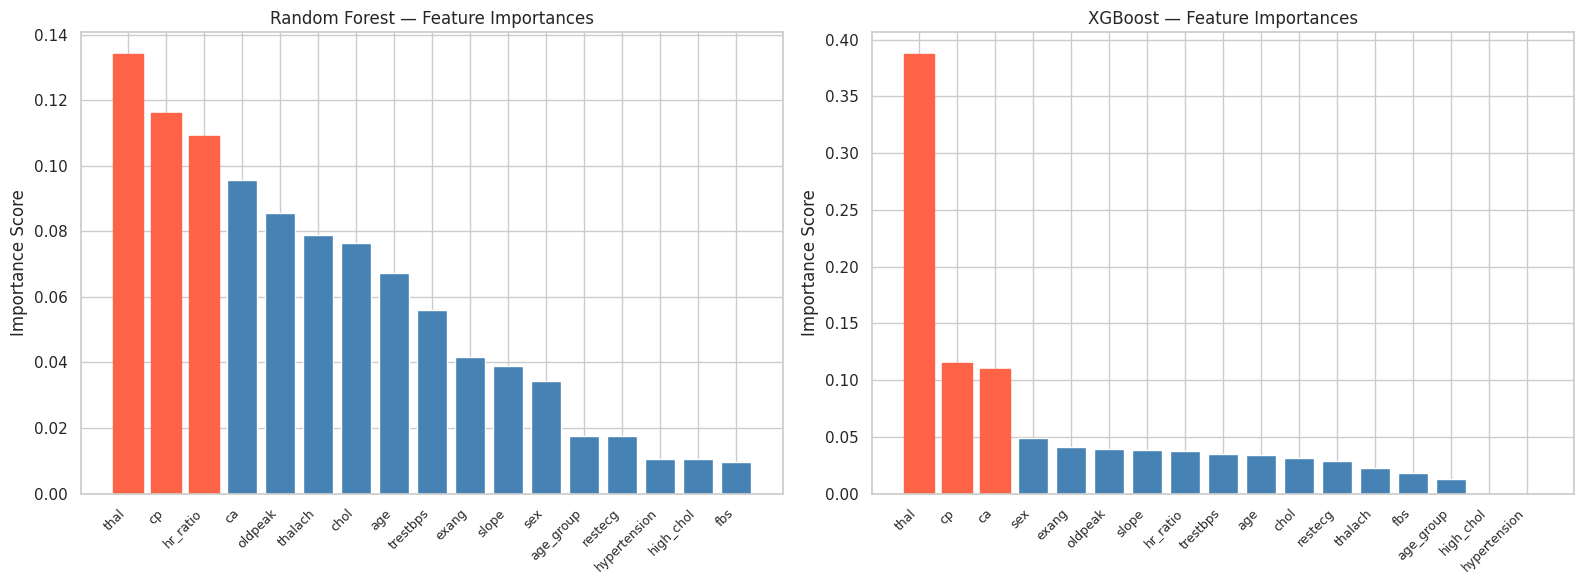

In [ ]:
feature_names = X.columns.tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for ax, model_name in zip([ax1, ax2], ['Random Forest', 'XGBoost']):
    model = results[model_name]['model']
    importances = model.feature_importances_
    idx = np.argsort(importances)[::-1]

    bars = ax.bar(range(len(importances)), importances[idx], color='steelblue', edgecolor='white')
    ax.set_xticks(range(len(importances)))
    ax.set_xticklabels([feature_names[i] for i in idx], rotation=45, ha='right', fontsize=9)
    ax.set_title(f"{model_name} — Feature Importances")
    ax.set_ylabel("Importance Score")
    # Color top-3 differently
    for j in range(3):
        bars[j].set_color('tomato')

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120, bbox_inches='tight')
plt.show()


## 10. SHAP Explainability (XGBoost)

Computing SHAP values for XGBoost (this may take ~10 seconds)...


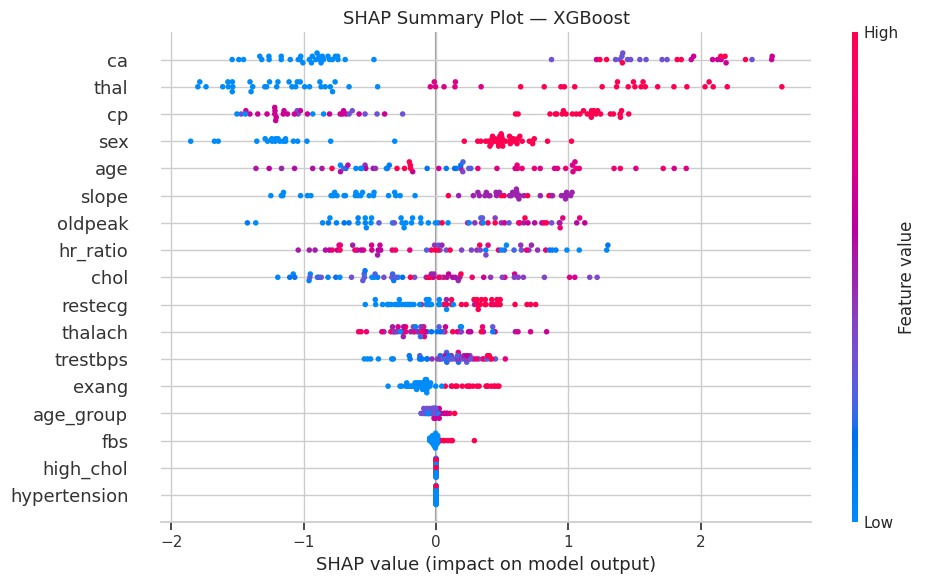

SHAP summary plot saved.


In [ ]:
print("Computing SHAP values for XGBoost (this may take ~10 seconds)...")
xgb_model = results['XGBoost']['model']
explainer  = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_s)

# Summary plot
plt.figure()
shap.summary_plot(shap_values, X_test_s, feature_names=feature_names,
                  show=False, plot_size=(10, 6))
plt.title("SHAP Summary Plot — XGBoost", fontsize=13)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=120, bbox_inches='tight')
plt.show()
print("SHAP summary plot saved.")


In [ ]:
# SHAP bar plot (mean absolute impact)
plt.figure()
shap.summary_plot(shap_values, X_test_s, feature_names=feature_names,
                  plot_type="bar", show=False, plot_size=(10, 5))
plt.title("SHAP Mean |Impact| per Feature", fontsize=13)
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=120, bbox_inches='tight')
plt.show()


## 11. Predict on a New Patient

In [ ]:
# Example new patient data (adjust values as needed)
new_patient = pd.DataFrame([{
    'age'      : 55,
    'sex'      : 1,
    'cp'       : 3,
    'trestbps' : 145,
    'chol'     : 270,
    'fbs'      : 0,
    'restecg'  : 1,
    'thalach'  : 150,
    'exang'    : 1,
    'oldpeak'  : 2.3,
    'slope'    : 1,
    'ca'       : 1,
    'thal'     : 3,
    'age_group': 2,
    'high_chol': 1,
    'hypertension': 1,
    'hr_ratio' : 150 / (220 - 55)
}])

# Scale using the same scaler
new_patient_s = scaler.transform(new_patient)

# Predict with all models
print("=" * 45)
print("🧑‍⚕️  PATIENT RISK ASSESSMENT")
print("=" * 45)
for name, r in results.items():
    model    = r['model']
    pred     = model.predict(new_patient_s)[0]
    prob     = model.predict_proba(new_patient_s)[0][1] * 100
    risk_str = "DISEASE DETECTED" if pred == 1 else "NO DISEASE"
    print(f"{name:<22}: {risk_str}  (Probability = {prob:.1f}%)")
print("=" * 45)


## 12. Save Best Model

In [ ]:
import pickle

# Choose best model by ROC-AUC
best_name = max(results, key=lambda k: results[k]['roc_auc'])
best_model = results[best_name]['model']

with open("best_heart_model.pkl", "wb") as f:
    pickle.dump({"model": best_model, "scaler": scaler,
                 "features": list(X.columns)}, f)

print(f"Best model: {best_name}  (ROC-AUC = {results[best_name]['roc_auc']:.4f})")
print("Saved to: best_heart_model.pkl")
print("\nClassification Report for Best Model:")
print(classification_report(y_test, results[best_name]['y_pred'],
                            target_names=['No Disease', 'Disease']))


> **Notebook complete!** All charts are saved as `.png` files and the best model is saved as `best_heart_model.pkl`.  
> You can download them from the Colab file browser (📁 left sidebar).
